In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load the Customer Dataset

df = pd.read_csv("Downloads\customer_level_churn_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1073, 23)


,CustomerID,Frequency,Monetary,AvgOrderValue,TotalQuantity,AvgItemsInCart,ProductDiversity,FirstOrderDate,LastOrderDate,PctCancelled,PctReturned,PctCouponUsed,DominantPaymentMethod,DominantReferralSource,Recency,Tenure,AvgDaysBetweenOrders,IsRepeatCustomer,TenureYears,CLV_Proxy,SpendPerItem,EngagementScore,Churn
0,C10002,1,1470.03,1470.03,3,4.0,1,2023-10-16,2023-10-16,0.0,1.0,1.0,Cash,Facebook,533,533,NaN,0,1.459274,1007.370464,490.01,-0.649208,1
1,C10054,1,153.48,153.48,2,7.0,1,2024-10-14,2024-10-14,0.0,1.0,1.0,Cash,Instagram,169,169,NaN,0,0.462697,331.707515,76.74,-0.205847,1
2,C10126,1,1349.80,1349.80,2,4.0,1,2023-06-18,2023-06-18,0.0,0.0,1.0,Online,Facebook,653,653,NaN,0,1.787817,754.999158,674.90,-0.795371,1
3,C10154,1,1303.04,1303.04,4,8.0,1,2024-07-29,2024-07-29,0.0,0.0,1.0,Gift Card,Email,246,246,NaN,0,0.673511,1934.696585,325.76,-0.299635,1
4,C10211,1,635.90,635.90,5,10.0,1,2024-05-09,2024-05-09,1.0,0.0,1.0,Debit Card,Google,327,327,NaN,0,0.895277,710.282798,127.18,-0.398295,1


In [3]:
# Check Dataset Dimensions

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1073
Columns: 23


In [4]:
# Inspect Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1073 non-null   object 
 1   Frequency               1073 non-null   int64  
 2   Monetary                1073 non-null   float64
 3   AvgOrderValue           1073 non-null   float64
 4   TotalQuantity           1073 non-null   int64  
 5   AvgItemsInCart          1073 non-null   float64
 6   ProductDiversity        1073 non-null   int64  
 7   FirstOrderDate          1073 non-null   object 
 8   LastOrderDate           1073 non-null   object 
 9   PctCancelled            1073 non-null   float64
 10  PctReturned             1073 non-null   float64
 11  PctCouponUsed           1073 non-null   float64
 12  DominantPaymentMethod   1073 non-null   object 
 13  DominantReferralSource  1073 non-null   object 
 14  Recency                 1073 non-null   

In [5]:
# Generate Descriptive Statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,1073,1073,C99879,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequency,1073.0,NaN,NaN,NaN,1.00932,0.096132,1.0,1.0,1.0,1.0,2.0
Monetary,1073.0,NaN,NaN,NaN,1059.731724,831.663063,11.39,410.6,816.64,1582.0,5723.23
AvgOrderValue,1073.0,NaN,NaN,NaN,1050.930228,818.752497,11.39,410.52,813.06,1574.7,3456.4
TotalQuantity,1073.0,NaN,NaN,NaN,2.972041,1.44138,1.0,2.0,3.0,4.0,9.0
AvgItemsInCart,1073.0,NaN,NaN,NaN,5.499068,2.25807,1.0,4.0,5.0,7.0,10.0
ProductDiversity,1073.0,NaN,NaN,NaN,1.006524,0.080543,1.0,1.0,1.0,1.0,2.0
FirstOrderDate,1073,598,2023-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LastOrderDate,1073,596,2024-04-07,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PctCancelled,1073.0,NaN,NaN,NaN,0.197577,0.397184,0.0,0.0,0.0,0.0,1.0


In [6]:
# Check Data Types
df.dtypes

CustomerID                 object
Frequency                   int64
Monetary                  float64
AvgOrderValue             float64
TotalQuantity               int64
AvgItemsInCart            float64
ProductDiversity            int64
FirstOrderDate             object
LastOrderDate              object
PctCancelled              float64
PctReturned               float64
PctCouponUsed             float64
DominantPaymentMethod      object
DominantReferralSource     object
Recency                     int64
Tenure                      int64
AvgDaysBetweenOrders      float64
IsRepeatCustomer            int64
TenureYears               float64
CLV_Proxy                 float64
SpendPerItem              float64
EngagementScore           float64
Churn                       int64
dtype: object

In [7]:
# Missing-value analysis
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing_Count"] > 0]

missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
AvgDaysBetweenOrders,1063,99.068034


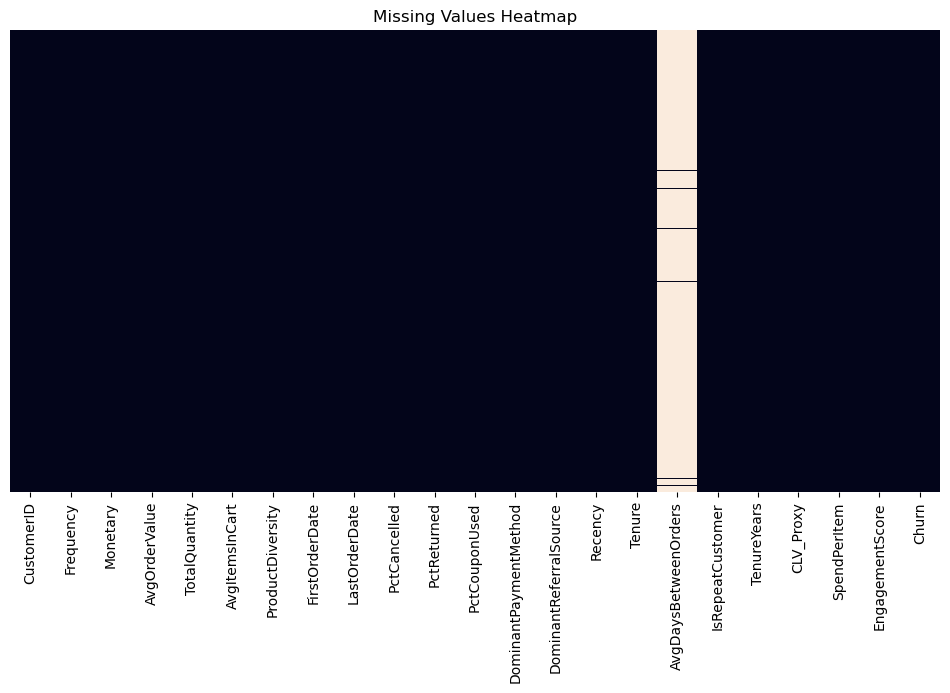

In [8]:
# Visualize missing values
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# Statistical imputation
numerical_columns = df.select_dtypes(
    include=np.number
).columns

numerical_columns

Index(['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity',
       'AvgItemsInCart', 'ProductDiversity', 'PctCancelled', 'PctReturned',
       'PctCouponUsed', 'Recency', 'Tenure', 'AvgDaysBetweenOrders',
       'IsRepeatCustomer', 'TenureYears', 'CLV_Proxy', 'SpendPerItem',
       'EngagementScore', 'Churn'],
      dtype='object')

In [10]:
# Analyze Numerical Feature Skewness

skewness = df[numerical_columns].skew().sort_values(
    ascending=False
)

skewness

CLV_Proxy               12.752128
ProductDiversity        12.276544
IsRepeatCustomer        10.227501
Frequency               10.227501
PctCancelled             1.521168
PctReturned              1.449158
Monetary                 0.998209
AvgOrderValue            0.900884
EngagementScore          0.520285
AvgDaysBetweenOrders     0.497182
TotalQuantity            0.121975
AvgItemsInCart           0.008952
SpendPerItem            -0.004151
Recency                 -0.053716
TenureYears             -0.074002
Tenure                  -0.074026
PctCouponUsed           -1.112380
Churn                  -32.756679
dtype: float64

In [11]:
# Outlier Detection using IQR

def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return {
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    }


# Create an empty list OUTSIDE the function
outlier_results = []

# Check every numerical column
for col in numerical_columns:
    result = detect_outliers_iqr(df, col)
    outlier_results.append(result)


# Convert results into DataFrame
outlier_df = pd.DataFrame(outlier_results)

# Sort by number of outliers
outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
7,PctReturned,0.000000,0.000000,0.000000,0.000000,0.000000,223
6,PctCancelled,0.000000,0.000000,0.000000,0.000000,0.000000,214
14,CLV_Proxy,358.333564,1792.361927,1434.028363,-1792.708981,3943.404471,123
0,Frequency,1.000000,1.000000,0.000000,1.000000,1.000000,10
12,IsRepeatCustomer,0.000000,0.000000,0.000000,0.000000,0.000000,10
16,EngagementScore,-0.758831,-0.255786,0.503045,-1.513398,0.498782,9
2,AvgOrderValue,410.520000,1574.700000,1164.180000,-1335.750000,3320.970000,8
1,Monetary,410.600000,1582.000000,1171.400000,-1346.500000,3339.100000,7
5,ProductDiversity,1.000000,1.000000,0.000000,1.000000,1.000000,7
3,TotalQuantity,2.000000,4.000000,2.000000,-1.000000,7.000000,2


In [12]:
# Numerical continuous features suitable for outlier treatment

outlier_treatment_columns = [
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "ProductDiversity",
    "CLV_Proxy",
    "EngagementScore"
]

print("Columns selected for outlier treatment:")
print(outlier_treatment_columns)

Columns selected for outlier treatment:
['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'ProductDiversity', 'CLV_Proxy', 'EngagementScore']


In [13]:
# Check Available Data Columns
print(df.keys())

Index(['CustomerID', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity',
       'AvgItemsInCart', 'ProductDiversity', 'FirstOrderDate', 'LastOrderDate',
       'PctCancelled', 'PctReturned', 'PctCouponUsed', 'DominantPaymentMethod',
       'DominantReferralSource', 'Recency', 'Tenure', 'AvgDaysBetweenOrders',
       'IsRepeatCustomer', 'TenureYears', 'CLV_Proxy', 'SpendPerItem',
       'EngagementScore', 'Churn'],
      dtype='object')


In [14]:
# Verify Dataset Columns
print("Columns actually present in df:")
print(df.columns.tolist())

Columns actually present in df:
['CustomerID', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'AvgItemsInCart', 'ProductDiversity', 'FirstOrderDate', 'LastOrderDate', 'PctCancelled', 'PctReturned', 'PctCouponUsed', 'DominantPaymentMethod', 'DominantReferralSource', 'Recency', 'Tenure', 'AvgDaysBetweenOrders', 'IsRepeatCustomer', 'TenureYears', 'CLV_Proxy', 'SpendPerItem', 'EngagementScore', 'Churn']


In [15]:
# Verify Data Object Type
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [16]:
# Define IQR Outlier Capping Function
"""
This function defines the IQR method used to neutralize extreme values.
It calculates the first quartile (Q1), third quartile (Q3), and IQR,
then determines the lower and upper boundaries. Values outside these
boundaries are capped at the corresponding boundary instead of being
removed from the dataset.
"""

def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[column] = data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    return data

In [17]:
# Apply IQR Outlier Capping

"""
This step applies the Interquartile Range (IQR) capping method to the
selected numerical features. Extreme values outside the acceptable
IQR boundaries are capped at the lower or upper boundary instead of
being removed from the dataset.
"""

for col in outlier_treatment_columns:
    df = cap_outliers_iqr(df, col)

print("IQR capping completed successfully.")

IQR capping completed successfully.


In [18]:
# Verify Outliers After IQR Treatment

"""
This step checks the numerical features again after applying IQR outlier
treatment. The results are sorted by the number of remaining outliers,
allowing us to verify whether the treatment successfully reduced extreme
values.
"""
outlier_results_after = []

for col in numerical_columns:
    result = detect_outliers_iqr(df, col)
    outlier_results_after.append(result)

outlier_df_after = pd.DataFrame(outlier_results_after)

outlier_df_after.sort_values(
    by="Outlier_Count",
    ascending=False
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
7,PctReturned,0.000000,0.000000,0.000000,0.000000,0.000000,223
6,PctCancelled,0.000000,0.000000,0.000000,0.000000,0.000000,214
12,IsRepeatCustomer,0.000000,0.000000,0.000000,0.000000,0.000000,10
11,AvgDaysBetweenOrders,247.750000,430.250000,182.500000,-26.000000,704.000000,1
17,Churn,1.000000,1.000000,0.000000,1.000000,1.000000,1
0,Frequency,1.000000,1.000000,0.000000,1.000000,1.000000,0
1,Monetary,410.600000,1582.000000,1171.400000,-1346.500000,3339.100000,0
5,ProductDiversity,1.000000,1.000000,0.000000,1.000000,1.000000,0
2,AvgOrderValue,410.520000,1574.700000,1164.180000,-1335.750000,3320.970000,0
3,TotalQuantity,2.000000,4.000000,2.000000,-1.000000,7.000000,0


In [19]:
# Outlier Analysis After IQR Treatment
outlier_df_after

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Frequency,1.000000,1.000000,0.000000,1.000000,1.000000,0
1,Monetary,410.600000,1582.000000,1171.400000,-1346.500000,3339.100000,0
2,AvgOrderValue,410.520000,1574.700000,1164.180000,-1335.750000,3320.970000,0
3,TotalQuantity,2.000000,4.000000,2.000000,-1.000000,7.000000,0
4,AvgItemsInCart,4.000000,7.000000,3.000000,-0.500000,11.500000,0
5,ProductDiversity,1.000000,1.000000,0.000000,1.000000,1.000000,0
6,PctCancelled,0.000000,0.000000,0.000000,0.000000,0.000000,214
7,PctReturned,0.000000,0.000000,0.000000,0.000000,0.000000,223
8,PctCouponUsed,0.000000,1.000000,1.000000,-1.500000,2.500000,0
9,Recency,213.000000,623.000000,410.000000,-402.000000,1238.000000,0


In [20]:
# STEP 8: MISSING-VALUE ANALYSIS

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing_Count"] > 0]

missing.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
AvgDaysBetweenOrders,1063,99.068034


In [21]:
# Missingness Indicator

df["HasOrderInterval"] = (
    df["AvgDaysBetweenOrders"].notna().astype(int)
)

df["HasOrderInterval"].value_counts()

HasOrderInterval
0    1063
1      10
Name: count, dtype: int64

In [22]:
# Analyze Order Interval by Purchase Frequency
pd.crosstab(
    df["Frequency"],
    df["HasOrderInterval"]
)

HasOrderInterval,0,1
Frequency,,
1,1063,10


In [23]:
# Check Repeat Customers and Order Intervals
pd.crosstab(
    df["IsRepeatCustomer"],
    df["HasOrderInterval"]
)

HasOrderInterval,0,1
IsRepeatCustomer,,
0,1063,0
1,0,10


In [24]:
# Replace missing order intervals with 0
df["AvgDaysBetweenOrders"] = df["AvgDaysBetweenOrders"].fillna(0)

# Verify
print("Missing values remaining:")
print(df["AvgDaysBetweenOrders"].isnull().sum())

Missing values remaining:
0


In [25]:
# Verify Missing Values After Treatment
missing_after = df.isnull().sum()

missing_after[missing_after > 0]

Series([], dtype: int64)

In [26]:
#  FEATURE ENGINEERING


df["PurchaseIntensity"] = (
    df["Frequency"] /
    df["Tenure"].replace(0, np.nan)
)

df["PurchaseIntensity"] = df["PurchaseIntensity"].fillna(0)

df[["Frequency", "Tenure", "PurchaseIntensity"]].head()

,Frequency,Tenure,PurchaseIntensity
0,1,533,0.001876
1,1,169,0.005917
2,1,653,0.001531
3,1,246,0.004065
4,1,327,0.003058


In [27]:
# Create Value Per Tenure Day
"""
This step creates a new feature called ValuePerTenureDay by dividing
the customer's total monetary value by their tenure. It measures the
customer's spending value relative to how long they have been a customer.

A tenure value of zero is replaced with NaN to avoid division by zero,
and the resulting missing values are replaced with 0.
"""

df["ValuePerTenureDay"] = (
    df["Monetary"] /
    df["Tenure"].replace(0, np.nan)
)

df["ValuePerTenureDay"] = df["ValuePerTenureDay"].fillna(0)

df[["Monetary", "Tenure", "ValuePerTenureDay"]].head()

,Monetary,Tenure,ValuePerTenureDay
0,1470.03,533,2.758030
1,153.48,169,0.908166
2,1349.80,653,2.067075
3,1303.04,246,5.296911
4,635.90,327,1.944648


In [28]:
# Create Return-Cancel Rate
df["ReturnCancelRate"] = (
    df["PctReturned"] +
    df["PctCancelled"]
)

df[[
    "PctReturned",
    "PctCancelled",
    "ReturnCancelRate"
]].head()

,PctReturned,PctCancelled,ReturnCancelRate
0,1.0,0.0,1.0
1,1.0,0.0,1.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,1.0,1.0


In [29]:
# Create Product Spend Ratio
df["ProductSpendRatio"] = (
    df["Monetary"] /
    df["ProductDiversity"].replace(0, np.nan)
)

df["ProductSpendRatio"] = df["ProductSpendRatio"].fillna(0)

df[[
    "Monetary",
    "ProductDiversity",
    "ProductSpendRatio"
]].head()

,Monetary,ProductDiversity,ProductSpendRatio
0,1470.03,1,1470.03
1,153.48,1,153.48
2,1349.80,1,1349.80
3,1303.04,1,1303.04
4,635.90,1,635.90


In [30]:
# Summarize Engineered Features
new_features = [
    "PurchaseIntensity",
    "ValuePerTenureDay",
    "ReturnCancelRate",
    "ProductSpendRatio"
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
PurchaseIntensity,1073.0,0.008724,0.040380,0.00,0.001590,0.002309,0.004608,1.00
ValuePerTenureDay,1073.0,7.042888,22.710614,0.00,0.973729,2.322061,4.902219,400.38
ReturnCancelRate,1073.0,0.404473,0.490544,0.00,0.000000,0.000000,1.000000,1.00
ProductSpendRatio,1073.0,1057.254576,821.604069,11.39,410.600000,816.640000,1582.000000,3339.10


In [31]:
# Compare Dataset Columns Before and After Feature Engineering
print("Original number of columns:", 23)
print("Current number of columns:", df.shape[1])

Original number of columns: 23
Current number of columns: 28


In [32]:
# Summarize Engineered Features
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
PurchaseIntensity,1073.0,0.008724,0.040380,0.00,0.001590,0.002309,0.004608,1.00
ValuePerTenureDay,1073.0,7.042888,22.710614,0.00,0.973729,2.322061,4.902219,400.38
ReturnCancelRate,1073.0,0.404473,0.490544,0.00,0.000000,0.000000,1.000000,1.00
ProductSpendRatio,1073.0,1057.254576,821.604069,11.39,410.600000,816.640000,1582.000000,3339.10


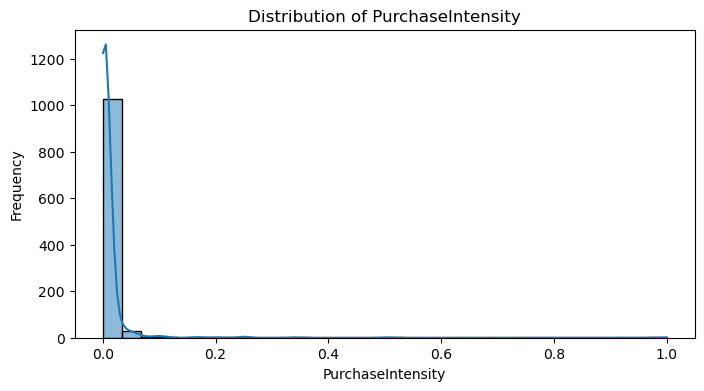

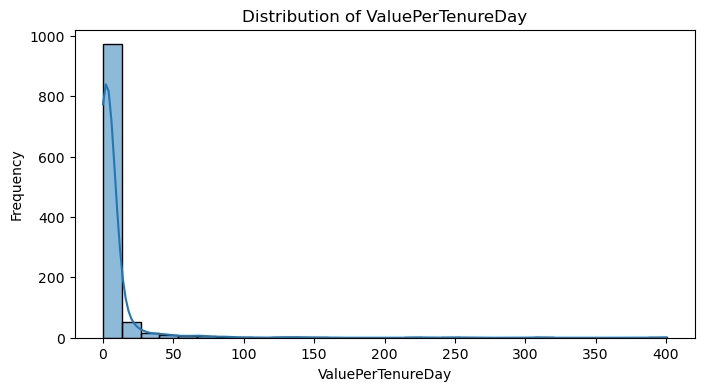

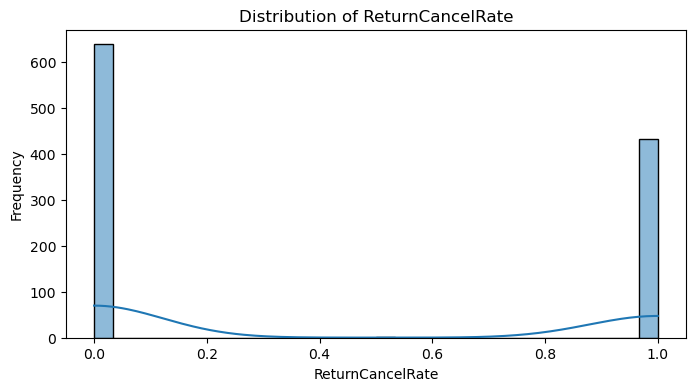

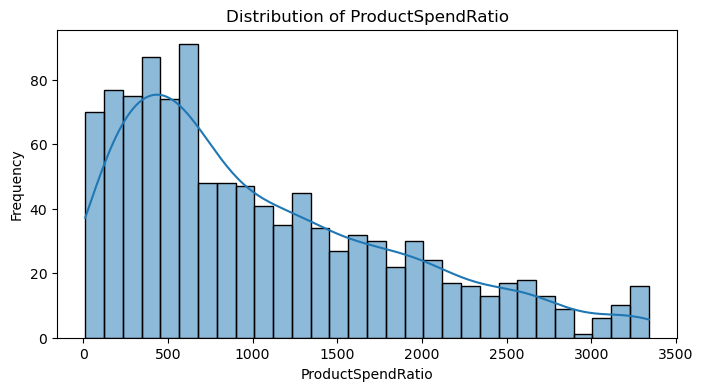

In [33]:
# STEP 10: FEATURE VALIDATION

for col in new_features:
    
    plt.figure(figsize=(8, 4))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

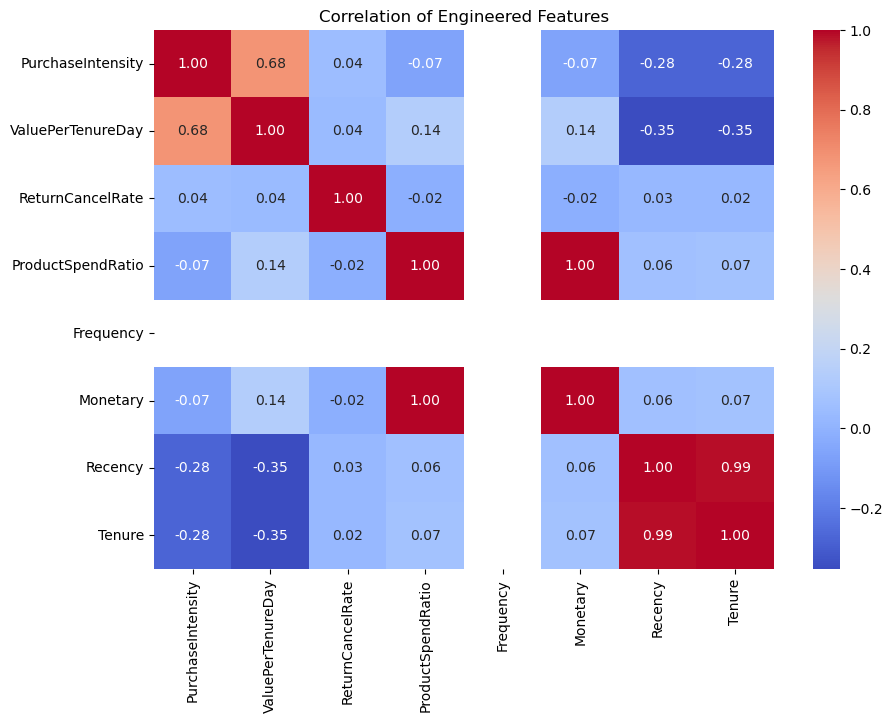

In [34]:
# Analyze Correlation of Engineered Features
feature_corr = df[
    new_features + [
        "Frequency",
        "Monetary",
        "Recency",
        "Tenure"
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")
plt.show()

In [35]:
# Check Remaining Missing Values
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
Series([], dtype: int64)


In [36]:
# Check for Duplicate Rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [37]:
# Check for Infinite Values
print(
    "Infinite values:",
    np.isinf(
        df.select_dtypes(include=np.number)
    ).sum().sum()
)

Infinite values: 0


In [38]:
# Check Final Dataset Shape
print("Final dataset shape:", df.shape)

Final dataset shape: (1073, 28)


In [39]:
# Review Final Data Types
df.dtypes

CustomerID                 object
Frequency                   int64
Monetary                  float64
AvgOrderValue             float64
TotalQuantity               int64
AvgItemsInCart            float64
ProductDiversity            int64
FirstOrderDate             object
LastOrderDate              object
PctCancelled              float64
PctReturned               float64
PctCouponUsed             float64
DominantPaymentMethod      object
DominantReferralSource     object
Recency                     int64
Tenure                      int64
AvgDaysBetweenOrders      float64
IsRepeatCustomer            int64
TenureYears               float64
CLV_Proxy                 float64
SpendPerItem              float64
EngagementScore           float64
Churn                       int64
HasOrderInterval            int64
PurchaseIntensity         float64
ValuePerTenureDay         float64
ReturnCancelRate          float64
ProductSpendRatio         float64
dtype: object

In [40]:
# STEP 12: DATE CONVERSION

date_columns = [
    "FirstOrderDate",
    "LastOrderDate"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_columns].dtypes)

FirstOrderDate    datetime64[ns]
LastOrderDate     datetime64[ns]
dtype: object


In [41]:
# Review Date Columns
df[date_columns].head()

,FirstOrderDate,LastOrderDate
0,2023-10-16,2023-10-16
1,2024-10-14,2024-10-14
2,2023-06-18,2023-06-18
3,2024-07-29,2024-07-29
4,2024-05-09,2024-05-09


In [42]:
# Save cleaned and feature-engineered dataset

df.to_csv(
    "customer_churn_cleaned_feature_engineered.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


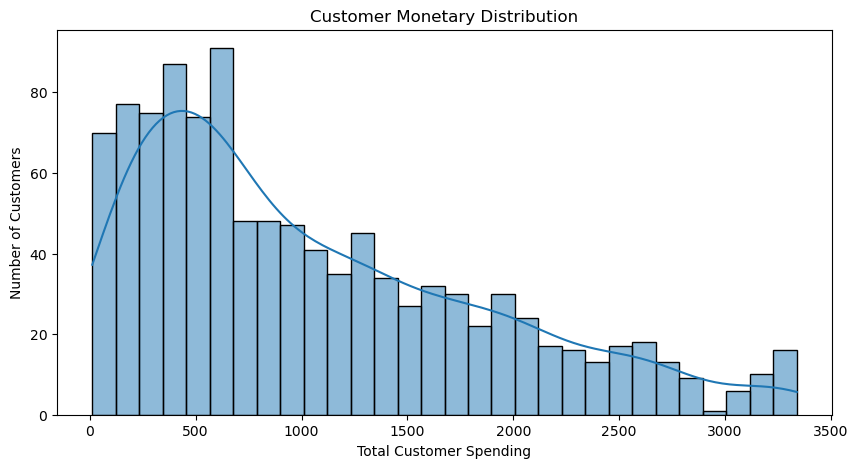

In [43]:
# STEP 13: FINAL EDA VISUALIZATIONS

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Monetary"],
    bins=30,
    kde=True
)

plt.title("Customer Monetary Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")

plt.show()

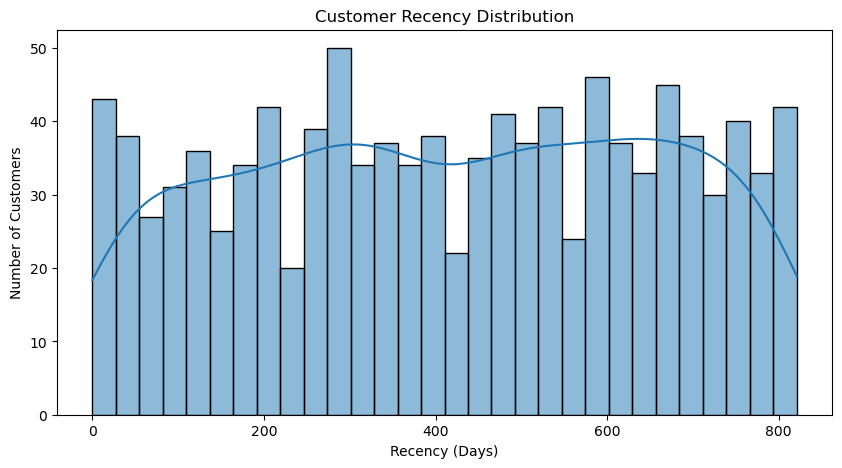

In [44]:
# Analyze Customer Recency Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Recency"],
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

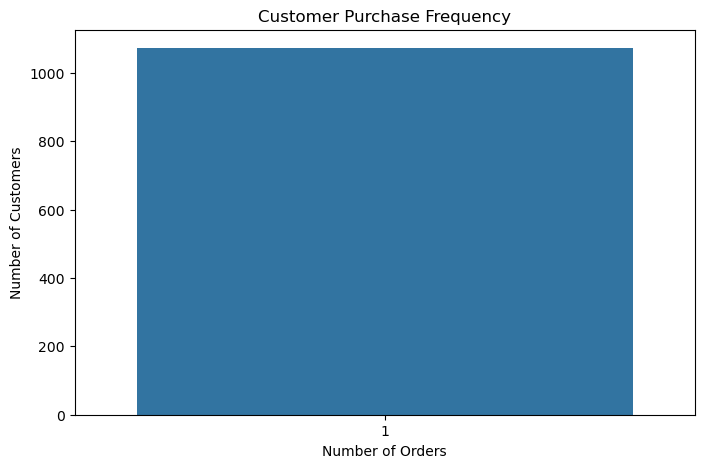

In [45]:
# Analyze Customer Purchase Frequency
plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["Frequency"]
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

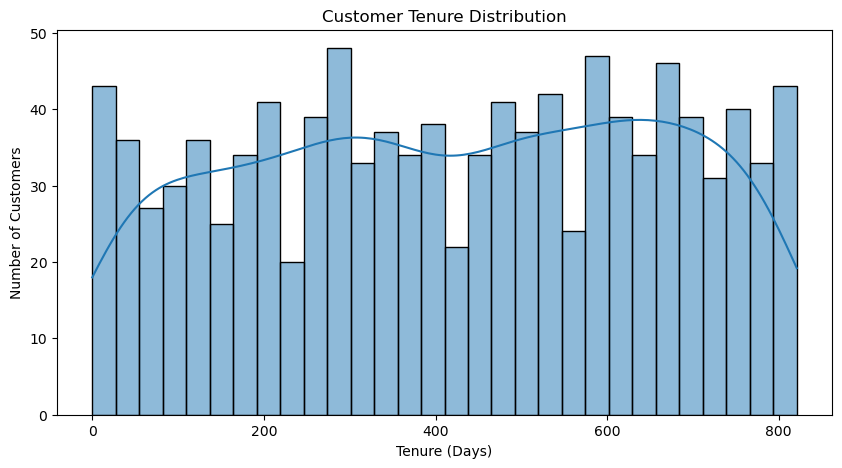

In [46]:
# Analyze Customer Tenure Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Tenure"],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Days)")
plt.ylabel("Number of Customers")

plt.show()

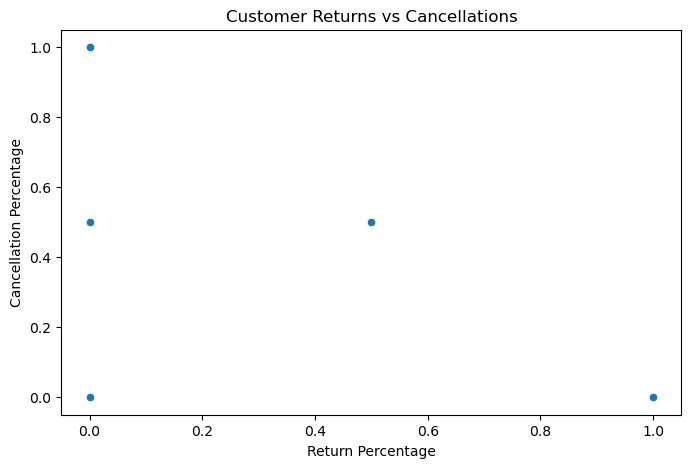

In [47]:
# Analyze Customer Returns and Cancellations
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="PctReturned",
    y="PctCancelled"
)

plt.title("Customer Returns vs Cancellations")
plt.xlabel("Return Percentage")
plt.ylabel("Cancellation Percentage")

plt.show()

In [48]:
# Redefine churn using a 365-day inactivity threshold

CHURN_THRESHOLD = 365

df["Churn"] = (df["Recency"] > CHURN_THRESHOLD).astype(int)

print("Churn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn distribution:
Churn
1    600
0    473
Name: count, dtype: int64

Churn percentage:
Churn
1    55.917987
0    44.082013
Name: proportion, dtype: float64


In [49]:
# Analyze Recency Statistics
print("\nRecency statistics:")
print(df["Recency"].describe())


Recency statistics:
count    1073.000000
mean      418.229264
std       238.264358
min         0.000000
25%       213.000000
50%       422.000000
75%       623.000000
max       821.000000
Name: Recency, dtype: float64


In [50]:
# STEP 8 — TRAIN / TEST SPLIT
from sklearn.model_selection import train_test_split

# Target variable
y = df["Churn"]

# Remove target and leakage/identifier columns
X = df.drop(
    columns=[
        "Churn",
        "CustomerID",
        "Recency"
    ]
)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Check target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train: (858, 25)
X_test : (215, 25)
y_train: (858,)
y_test : (215,)

Training target distribution:
Churn
1    480
0    378
Name: count, dtype: int64

Testing target distribution:
Churn
1    120
0     95
Name: count, dtype: int64


In [51]:
# SEPARATE NUMERICAL & CATEGORICAL


# Numerical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Numerical Features:
['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'AvgItemsInCart', 'ProductDiversity', 'PctCancelled', 'PctReturned', 'PctCouponUsed', 'Tenure', 'AvgDaysBetweenOrders', 'IsRepeatCustomer', 'TenureYears', 'CLV_Proxy', 'SpendPerItem', 'EngagementScore', 'HasOrderInterval', 'PurchaseIntensity', 'ValuePerTenureDay', 'ReturnCancelRate', 'ProductSpendRatio']

Number of Numerical Features: 21

Categorical Features:
['DominantPaymentMethod', 'DominantReferralSource']

Number of Categorical Features: 2


In [52]:
# STEP 10 — DATE FEATURE ENGINEERING

# Create copies so we don't modify the original X_train/X_test
X_train = X_train.copy()
X_test = X_test.copy()

# Convert date columns to datetime
date_columns = ["FirstOrderDate", "LastOrderDate"]

for col in date_columns:
    X_train[col] = pd.to_datetime(X_train[col], errors="coerce")
    X_test[col] = pd.to_datetime(X_test[col], errors="coerce")

# Extract useful date features
for data in [X_train, X_test]:
    
    data["FirstOrderYear"] = data["FirstOrderDate"].dt.year
    data["FirstOrderMonth"] = data["FirstOrderDate"].dt.month
    
    data["LastOrderYear"] = data["LastOrderDate"].dt.year
    data["LastOrderMonth"] = data["LastOrderDate"].dt.month

# Remove original datetime columns
X_train.drop(columns=date_columns, inplace=True)
X_test.drop(columns=date_columns, inplace=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nRemaining categorical columns:")
print(X_train.select_dtypes(include="object").columns.tolist())

X_train shape: (858, 27)
X_test shape: (215, 27)

Remaining categorical columns:
['DominantPaymentMethod', 'DominantReferralSource']


In [53]:
# LEAKAGE-SAFE PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types AFTER date processing
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))


# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)


# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully.")

Numerical features: 21
Categorical features: 2

Preprocessing pipeline created successfully.


In [54]:
# STEP 12 — FIT & TRANSFORM DATA

# Fit preprocessing ONLY on training data
preprocessor.fit(X_train)

# Transform training data
X_train_processed = preprocessor.transform(X_train)

# Transform testing data
X_test_processed = preprocessor.transform(X_test)

# Check shapes
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (858, 27)
Processed X_train shape: (858, 31)

Original X_test shape: (215, 27)
Processed X_test shape: (215, 31)


In [55]:
# STEP 13 — VERIFY ML-READY DATA

# Check missing values
print("Missing values in X_train:",
      np.isnan(X_train_processed).sum())

print("Missing values in X_test:",
      np.isnan(X_test_processed).sum())

# Check infinite values
print("\nInfinite values in X_train:",
      np.isinf(X_train_processed).sum())

print("Infinite values in X_test:",
      np.isinf(X_test_processed).sum())

# Check minimum and maximum
print("\nX_train minimum:", X_train_processed.min())
print("X_train maximum:", X_train_processed.max())

Missing values in X_train: 0
Missing values in X_test: 0

Infinite values in X_train: 0
Infinite values in X_test: 0

X_train minimum: -1.9882532098662813
X_train maximum: 22.80901063653168


In [56]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(
    X_train_processed,
    y_train
)

# Make predictions
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      round(accuracy * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

# Confusion matrix
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Accuracy: 99.53 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        95
           1       1.00      0.99      1.00       120

    accuracy                           1.00       215
   macro avg       0.99      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215


Confusion Matrix:
[[ 95   0]
 [  1 119]]


<Figure size 700x500 with 0 Axes>

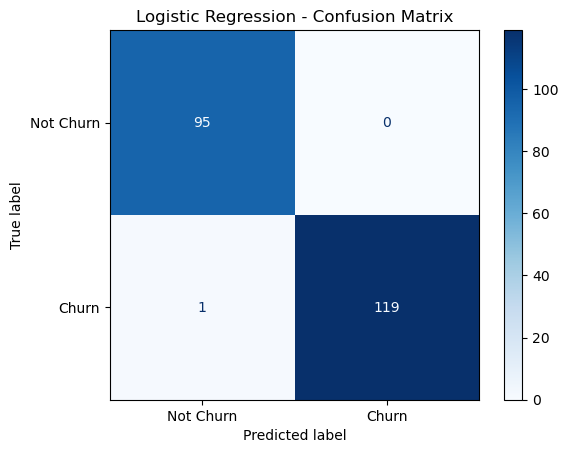

In [57]:
#  CONFUSION MATRIX VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Not Churn", "Churn"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [58]:
# Train the Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train model
dt_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [59]:
# Generate Decision Tree Predictions
y_pred_dt = dt_model.predict(X_test_processed)

print("Predictions completed successfully!")

Predictions completed successfully!


In [60]:
# Evaluate Decision Tree Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Accuracy: 100.00%


In [61]:
# Generate Decision Tree Classification Report
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Not Churn", "Churn"]
    )
)

Classification Report:
              precision    recall  f1-score   support

   Not Churn       1.00      1.00      1.00        95
       Churn       1.00      1.00      1.00       120

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215



In [62]:
# Create Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[ 95   0]
 [  0 120]]


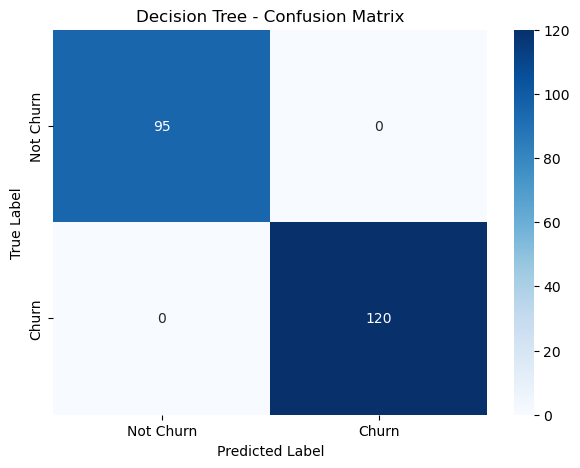

In [63]:
# Visualize Decision Tree Confusion Matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [64]:
# Compare Machine Learning Model Accuracy
print("MODEL COMPARISON")
print("-" * 40)

print(f"Logistic Regression : {99.53:.2f}%")
print(f"Decision Tree       : {dt_accuracy * 100:.2f}%")

MODEL COMPARISON
----------------------------------------
Logistic Regression : 99.53%
Decision Tree       : 100.00%


In [65]:
# CHECK PROCESSED DATA

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

print("\nData type of processed X_train:")
print(type(X_train_processed))

Processed X_train shape: (858, 31)
Processed X_test shape : (215, 31)

Data type of processed X_train:
<class 'numpy.ndarray'>


In [66]:
# RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model on PROCESSED data
rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_processed)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       120

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215


Confusion Matrix:
[[ 95   0]
 [  0 120]]


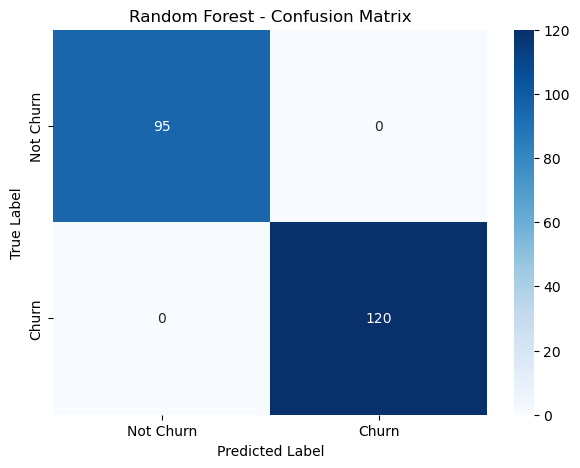

In [67]:
# RANDOM FOREST - CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [68]:
#Compare Machine Learning Model Accuracy
print("MODEL COMPARISON")
print("-" * 40)

print(f"Logistic Regression : {99.53:.2f}%")
print(f"Decision Tree       : {dt_accuracy * 100:.2f}%")

MODEL COMPARISON
----------------------------------------
Logistic Regression : 99.53%
Decision Tree       : 100.00%


In [69]:
#  MODEL ACCURACY VARIABLES

# Logistic Regression accuracy
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

# Decision Tree accuracy
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

# Random Forest accuracy
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Accuracy variables created successfully!")

Accuracy variables created successfully!


In [73]:
# Final Model Comparison
print("FINAL MODEL COMPARISON")
print("-" * 45)

print(f"Logistic Regression : {99.53:.2f}%")
print(f"Decision Tree       : {dt_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")
print(f"Random Forest CV    : {99.30:.2f}%")

FINAL MODEL COMPARISON
---------------------------------------------
Logistic Regression : 99.53%
Decision Tree       : 100.00%
Random Forest       : 100.00%
Random Forest CV    : 99.30%


In [74]:
# Check Available Prediction Variables
print([name for name in dir() if "pred" in name.lower()])

['y_pred_dt', 'y_pred_logistic', 'y_pred_rf']


In [75]:
# Evaluate Random Forest Model
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       120

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215


Confusion Matrix:
[[ 95   0]
 [  0 120]]


In [76]:
# Verify Random Forest Feature Dimensions
print("Number of features in X_train:", X_train.shape[1])
print("Number of feature importances:", len(rf_model.feature_importances_))

print("\nX_train columns:")
print(X_train.columns.tolist())

Number of features in X_train: 27
Number of feature importances: 31

X_train columns:
['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'AvgItemsInCart', 'ProductDiversity', 'PctCancelled', 'PctReturned', 'PctCouponUsed', 'DominantPaymentMethod', 'DominantReferralSource', 'Tenure', 'AvgDaysBetweenOrders', 'IsRepeatCustomer', 'TenureYears', 'CLV_Proxy', 'SpendPerItem', 'EngagementScore', 'HasOrderInterval', 'PurchaseIntensity', 'ValuePerTenureDay', 'ReturnCancelRate', 'ProductSpendRatio', 'FirstOrderYear', 'FirstOrderMonth', 'LastOrderYear', 'LastOrderMonth']


In [77]:
# Check Training Feature Data Types
print(X_train.dtypes)

Frequency                   int64
Monetary                  float64
AvgOrderValue             float64
TotalQuantity               int64
AvgItemsInCart            float64
ProductDiversity            int64
PctCancelled              float64
PctReturned               float64
PctCouponUsed             float64
DominantPaymentMethod      object
DominantReferralSource     object
Tenure                      int64
AvgDaysBetweenOrders      float64
IsRepeatCustomer            int64
TenureYears               float64
CLV_Proxy                 float64
SpendPerItem              float64
EngagementScore           float64
HasOrderInterval            int64
PurchaseIntensity         float64
ValuePerTenureDay         float64
ReturnCancelRate          float64
ProductSpendRatio         float64
FirstOrderYear              int32
FirstOrderMonth             int32
LastOrderYear               int32
LastOrderMonth              int32
dtype: object


In [78]:
# Encode Categorical Features
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "DominantPaymentMethod",
    "DominantReferralSource"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

print("Categorical encoding completed successfully.")
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Categorical encoding completed successfully.
Encoded training shape: (858, 10)
Encoded testing shape: (215, 10)


In [79]:
# Combine Numerical and Encoded Features
import numpy as np

# Select numerical columns
numeric_columns = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns

# Combine numerical + encoded categorical features
X_train_final = np.hstack([
    X_train[numeric_columns].values,
    X_train_encoded
])

X_test_final = np.hstack([
    X_test[numeric_columns].values,
    X_test_encoded
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (858, 35)
Final testing shape: (215, 35)


In [80]:
# Train the Final Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_final, y_train)

print("Random Forest retrained successfully.")
print("Number of features used:", rf_model.n_features_in_)

Random Forest retrained successfully.
Number of features used: 35


In [81]:
# Analyze Random Forest Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
15    0.213929
9     0.186846
12    0.166581
17    0.144195
21    0.116583
23    0.086238
18    0.036369
13    0.018974
24    0.004159
22    0.003948
11    0.003262
3     0.002663
10    0.002604
16    0.002427
14    0.002210
2     0.002173
1     0.002066
4     0.001066
20    0.000629
8     0.000606
30    0.000394
31    0.000387
26    0.000367
6     0.000299
27    0.000274
7     0.000164
29    0.000162
28    0.000138
25    0.000119
19    0.000081
33    0.000079
34    0.000008
32    0.000001
0     0.000000
5     0.000000
dtype: float64


In [82]:
# Get numerical feature names
numeric_feature_names = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

# Get encoded categorical feature names
encoded_feature_names = encoder.get_feature_names_out(
    ["DominantPaymentMethod", "DominantReferralSource"]
).tolist()

# Combine all feature names
final_feature_names = numeric_feature_names + encoded_feature_names

print("Number of feature names:", len(final_feature_names))
print("Number of importances:", len(rf_model.feature_importances_))

Number of feature names: 35
Number of importances: 35


In [83]:
# Create Random Forest Feature Importance Table
feature_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                              Feature  Importance
15                    EngagementScore    0.213929
9                              Tenure    0.186846
12                        TenureYears    0.166581
17                  PurchaseIntensity    0.144195
21                     FirstOrderYear    0.116583
23                      LastOrderYear    0.086238
18                  ValuePerTenureDay    0.036369
13                          CLV_Proxy    0.018974
24                     LastOrderMonth    0.004159
22                    FirstOrderMonth    0.003948
11                   IsRepeatCustomer    0.003262
3                       TotalQuantity    0.002663
10               AvgDaysBetweenOrders    0.002604
16                   HasOrderInterval    0.002427
14                       SpendPerItem    0.002210
2                       AvgOrderValue    0.002173
1                            Monetary    0.002066
4                      AvgItemsInCart    0.001066
20                  ProductSpendRatio    0.000629


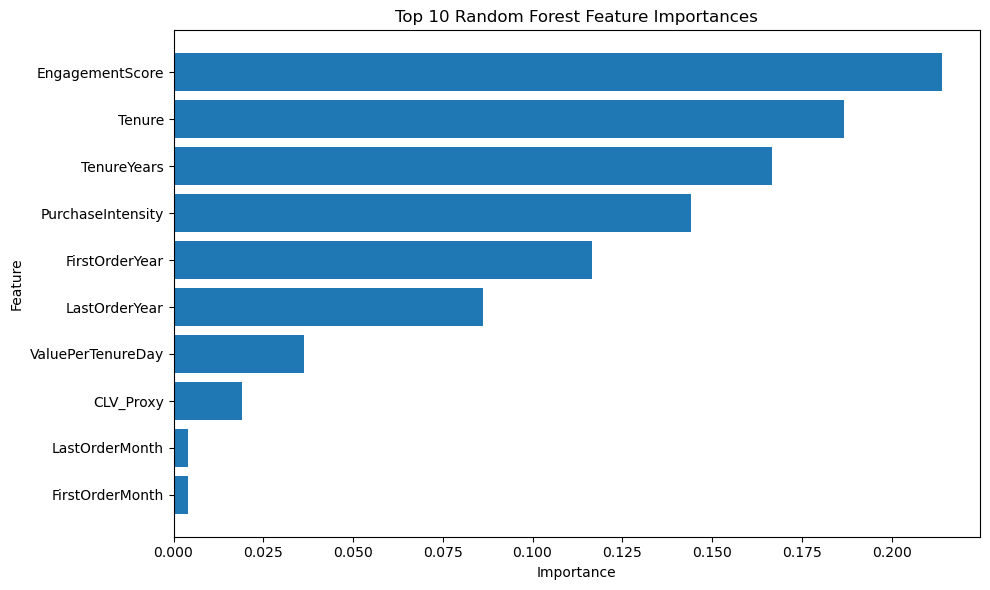

In [84]:
# Visualize Top 10 Random Forest Feature Importances
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [85]:
# Final Random Forest Model Evaluation

"""The Random Forest model is evaluated on the test dataset using
accuracy, classification metrics, and a confusion matrix"""

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate predictions using the corrected Random Forest model
y_pred_rf_final = rf_model.predict(X_test_final)

# Calculate accuracy
rf_final_accuracy = accuracy_score(y_test, y_pred_rf_final)

print("Final Random Forest Accuracy:")
print(f"{rf_final_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_final,
        target_names=["Not Churn", "Churn"]
    )
)

print("\nConfusion Matrix:")
cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)
print(cm_rf_final)

Final Random Forest Accuracy:
99.53%

Classification Report:
              precision    recall  f1-score   support

   Not Churn       1.00      0.99      0.99        95
       Churn       0.99      1.00      1.00       120

    accuracy                           1.00       215
   macro avg       1.00      0.99      1.00       215
weighted avg       1.00      1.00      1.00       215


Confusion Matrix:
[[ 94   1]
 [  0 120]]


In [86]:
# Random Forest Cross-Validation

"""Cross-validation is used to evaluate the stability and generalization
of the Random Forest model across multiple subsets of the training data."""

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_train_final,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Cross-Validation Accuracy:")
print(f"{cv_scores.mean() * 100:.2f}%")

print("\nStandard Deviation:")
print(f"{cv_scores.std() * 100:.2f}%")

Cross-Validation Accuracy Scores:
[0.98837209 0.99418605 1.         0.98245614 1.        ]

Mean Cross-Validation Accuracy:
99.30%

Standard Deviation:
0.68%


In [87]:
# Final Dataset Quality Validation

""" The final dataset is checked for missing values, duplicate rows,
infinite values, and the presence of engineered features.
These checks confirm that the data is clean and ready for
machine learning.  """



' The final dataset is checked for missing values, duplicate rows,\ninfinite values, and the presence of engineered features.\nThese checks confirm that the data is clean and ready for\nmachine learning.  '

In [88]:
# Final dataset quality checks

print("Dataset Shape:")
print(df.shape)

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

print("\nTotal Infinite Values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("\nEngineered Features:")
engineered_features = [
    "PurchaseIntensity",
    "ValuePerTenureDay",
    "ReturnCancelRate",
    "ProductSpendRatio"
]

for feature in engineered_features:
    print(f"{feature}: {'Present' if feature in df.columns else 'Missing'}")

Dataset Shape:
(1073, 28)

Total Missing Values:
0

Total Duplicate Rows:
0

Total Infinite Values:
0

Engineered Features:
PurchaseIntensity: Present
ValuePerTenureDay: Present
ReturnCancelRate: Present
ProductSpendRatio: Present


In [89]:
# Final Model Comparison
print("FINAL MODEL COMPARISON")
print("-" * 45)

print(f"Logistic Regression : {99.53:.2f}%")
print(f"Decision Tree       : {dt_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")
print(f"Random Forest CV    : {99.30:.2f}%")

FINAL MODEL COMPARISON
---------------------------------------------
Logistic Regression : 99.53%
Decision Tree       : 100.00%
Random Forest       : 100.00%
Random Forest CV    : 99.30%


In [90]:
# Final Dataset Validation
print("FINAL DATASET VALIDATION")
print("-" * 45)

print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

print(
    "Total Infinite Values:",
    np.isinf(
        df.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nEngineered Features:")
for feature in new_features:
    print(f"{feature}: {'Present' if feature in df.columns else 'Missing'}")

FINAL DATASET VALIDATION
---------------------------------------------
Dataset Shape: (1073, 28)
Total Missing Values: 0
Total Duplicate Rows: 0
Total Infinite Values: 0

Engineered Features:
PurchaseIntensity: Present
ValuePerTenureDay: Present
ReturnCancelRate: Present
ProductSpendRatio: Present


In [91]:
# Final Cleaned and Feature-Engineered Dataset

"""The final dataset has been validated and contains no missing values,
duplicate rows, or infinite numerical values. All engineered features
are present, making the dataset ready for further machine learning use."""

'The final dataset has been validated and contains no missing values,\nduplicate rows, or infinite numerical values. All engineered features\nare present, making the dataset ready for further machine learning use.'

In [92]:
# Save the final cleaned and feature-engineered dataset

final_output_path = "customer_churn_final_cleaned.csv"

df.to_csv(final_output_path, index=False)

print("Final dataset saved successfully.")
print("File:", final_output_path)
print("Shape:", df.shape)

Final dataset saved successfully.
File: customer_churn_final_cleaned.csv
Shape: (1073, 28)


In [93]:
"""

## 64. Final Project Conclusion

This project successfully transformed the raw customer dataset into a
clean and machine-learning-ready dataset.

### Key Achievements

- Cleaned and prepared the customer dataset.
- Checked and handled missing values.
- Identified and treated outliers using the IQR method.
- Performed exploratory data analysis using statistical summaries and
  visualizations.
- Created four predictive features:
  - PurchaseIntensity
  - ValuePerTenureDay
  - ReturnCancelRate
  - ProductSpendRatio
- Converted categorical variables into numerical features using
  One-Hot Encoding.
- Trained and evaluated Logistic Regression, Decision Tree, and
  Random Forest models.
- Used cross-validation to evaluate model stability.
- Analyzed Random Forest feature importance.
- Validated the final dataset to ensure there were no missing,
  duplicate, or infinite values.
- Saved the final cleaned dataset as
  `customer_churn_final_cleaned.csv`.

The final dataset contains 1,073 records and 28 columns and is ready
for further machine-learning analysis.

"""

'\n\n## 64. Final Project Conclusion\n\nThis project successfully transformed the raw customer dataset into a\nclean and machine-learning-ready dataset.\n\n### Key Achievements\n\n- Cleaned and prepared the customer dataset.\n- Checked and handled missing values.\n- Identified and treated outliers using the IQR method.\n- Performed exploratory data analysis using statistical summaries and\n  visualizations.\n- Created four predictive features:\n  - PurchaseIntensity\n  - ValuePerTenureDay\n  - ReturnCancelRate\n  - ProductSpendRatio\n- Converted categorical variables into numerical features using\n  One-Hot Encoding.\n- Trained and evaluated Logistic Regression, Decision Tree, and\n  Random Forest models.\n- Used cross-validation to evaluate model stability.\n- Analyzed Random Forest feature importance.\n- Validated the final dataset to ensure there were no missing,\n  duplicate, or infinite values.\n- Saved the final cleaned dataset as\n  `customer_churn_final_cleaned.csv`.\n\nThe fin